In [2]:
import os

import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
data_folder = "../../data/preprocessed-data"

df_rois = pd.concat(
    [pd.read_hdf(os.path.join(data_folder, f'df_eyewire2_roi_level_GCL{i}.h5'), key='dataframe') for i in range(5)])

array([12, 34, 42, 46, 28, 38, 14, 16, 33, 42, 33, 42, 46, 33, 30, 33, 25,
       44, 38,  9, 42,  5, 46,  3, 10, 46, 32, 42, 42, 23, 34, 42, 14, 44,
       42, 42, 33, 34, 42,  1, 42, 37, 27, 40, 30, 37, 30, 14, 31, 30, 13,
       27, 46, 11, 37, 17, 42, 17, 14, 33, 42, 42, 12, 14, 42, 32, 40, 42,
       13, 42,  4, 42, 42, 18, 38, 14, 28, 42, 34, 34, 42, 42, 46, 11, 42,
       17, 38, 26, 37, 13, 42, 10, 44, 46, 14, 31, 46, 42, 41, 33, 12, 43,
       35, 42, 43, 11, 46, 38, 45, 31, 42, 43, 17, 32, 13, 14, 37, 32, 35,
       14, 42, 10, 32, 12, 43, 14, 46, 11, 32, 43, 28, 17, 18, 31, 46, 46,
        5,  9, 29,  1, 12, 31, 31, 26, 34, 46, 31, 42, 38, 31, 12, 31, 32,
       17, 42, 46, 46, 17, 44, 42,  4, 46, 43, 12, 43, 43, 42, 13, 43, 43,
       27,  4, 28, 31, 31, 42,  6,  7, 31, 32, 42, 42, 42, 42, 42, 31, 42,
       42, 43, 31, 31, 36, 11, 31, 26, 31, 38, 38, 31, 36,  4, 31, 31, 42,
       11, 46, 31, 10, 10, 17, 31, 12, 46, 42, 31, 35,  7, 31, 35, 14, 33,
       31, 31,  7, 31,  6

In [45]:
from scipy import ndimage
import numpy as np

def downsample_uniform_filter(data, n):
    """Downsample using uniform filter - works with any array size"""
    filtered = ndimage.uniform_filter1d(data, size=n, axis=1)
    return filtered[:, ::n]

In [31]:
chirps = np.vstack(df_rois['chirp_average_norm'])

In [44]:
chirps.shape

(379, 1982)

In [32]:
bars = np.vstack(df_rois['bar_time_component'])

In [165]:
sidx = np.argsort(df_rois.group_id.values)[::-1]

In [166]:
import h5py

try:
    with h5py.File("X:/Resources/Stimulus/chirp.h5", "r") as f:
        chirp_stimulus = f['stimulusarray'][:].T.astype(int)
    chirp_stimulus = np.append(chirp_stimulus, np.full(1000, chirp_stimulus[-1]))
except:
    chirp_stimulus = np.ones(32988).astype(int)

In [167]:
import seaborn as sns

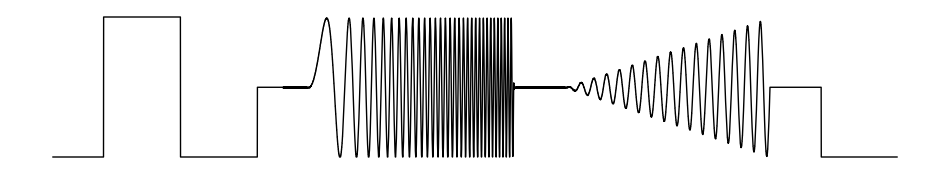

In [190]:
fig, ax = plt.subplots(1, 1, figsize=(12, 2))

ax.axis('off')
ax.plot(np.arange(len(chirp_stimulus))*1e-3, chirp_stimulus, c='k', clip_on=False, lw=1, solid_capstyle='butt')
plt.savefig('figures/chirp_stimulus.eps', bbox_inches='tight')

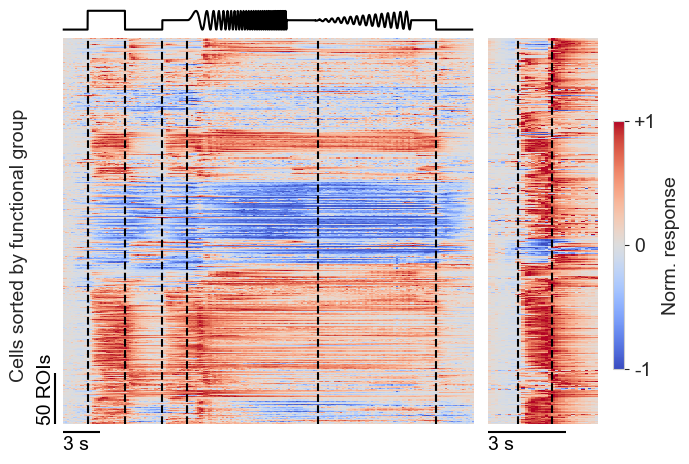

In [198]:
f_ds = 10

fig, axs = plt.subplots(2, 3, figsize=(7, 5), width_ratios=(12, 3, 0.3), height_ratios=(1, 20), sharex='col')
sns.despine(left=1, bottom=1)

ax = axs[0, 0]
ax.axis('off')
ax.plot(np.arange(len(chirp_stimulus))*1e-3, chirp_stimulus, c='k', clip_on=False, lw=1.5, solid_capstyle='butt')

ax = axs[1, 0]
ax.grid(False)
ax.set(xticks=[], yticks=[])
ax.set_ylabel('Cells sorted by functional group', fontsize=14)
ax.imshow(downsample_uniform_filter(data=chirps[sidx], n=f_ds), aspect='auto', vmin=-1, vmax=1, cmap='coolwarm', interpolation='none', extent=(0, 33, 0, 1), origin='lower')
for t in [2, 5, 8, 10, 20.5, 30]:
    ax.plot([t, t], [0, 1], c='k', lw=1.5, ls='--')
ax.plot([0, 3], [-.02, -.02], c='k', solid_capstyle='butt')
ax.text(0, -0.03, '3 s', c='k', ha='left', rotation=0, va='top', fontsize=14)

ax.plot([-0.02*33, -0.02*33], [0, 50/len(sidx)], c='k', solid_capstyle='butt')
ax.text(-0.02*33, 0, f'50 ROIs', c='k', ha='right', rotation=90, va='bottom', fontsize=14)

ax = axs[0, 1]
ax.axis('off')

ax = axs[0, 2]
ax.axis('off')

ax = axs[1, 1]
ax.grid(False)
ax.axis('off')
im = ax.imshow(bars[sidx], aspect='auto', vmin=-1, vmax=1, cmap='coolwarm', interpolation='none', extent=(0, 4.224, 0, 1), origin='lower')

for t in [1.152, 2.432]:
    ax.plot([t, t], [0, 1], c='k', lw=1.5, ls='--')
ax.plot([0, 3], [-.02, -.02], c='k', solid_capstyle='butt')
ax.text(0, -0.03, '3 s', c='k', ha='left', rotation=0, va='top', fontsize=14)

ax = axs[1, 2]
cbar = plt.colorbar(im, ax=ax, cax=ax, orientation='vertical')
cbar.set_label('Norm. response', fontsize=14)
cbar.set_ticks([-1, 0, 1])
cbar.set_ticklabels(["-1", "0", "+1"], fontsize=14)

plt.tight_layout(h_pad=0.05)

pos = ax.get_position()
new_pos = [pos.x0, pos.y0 + pos.height*0.2, pos.width, pos.height*0.6]
ax.set_position(new_pos)

plt.savefig('figures/response_overview.svg', bbox_inches='tight')